In [1]:
# ------------------------
# Dummy baseline for Kaggle submission
# Generates random multi-label predictions
# ------------------------
import os
import csv
import random
from tqdm import tqdm

# --- Paths ---
TEST_DIR = "Amazon_products/test"  # modify if needed
TEST_CORPUS_PATH = os.path.join(TEST_DIR, "test_corpus.txt")  # product_id \t text
SUBMISSION_PATH = "submission.csv"  # output file

# --- Constants ---
NUM_CLASSES = 531  # total number of classes (0–530)
MIN_LABELS = 1     # minimum number of labels per sample
MAX_LABELS = 3     # maximum number of labels per sample

# --- Load test corpus ---
def load_corpus(path):
    """Load test corpus into {pid: text} dictionary."""
    pid2text = {}
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split("\t", 1)
            if len(parts) == 2:
                pid, text = parts
                pid2text[pid] = text
    return pid2text

pid2text_test = load_corpus(TEST_CORPUS_PATH)
pid_list_test = list(pid2text_test.keys())

# --- Generate random predictions ---
all_pids, all_labels = [], []
for pid in tqdm(pid_list_test, desc="Generating dummy predictions"):
    n_labels = random.randint(MIN_LABELS, MAX_LABELS)
    labels = random.sample(range(NUM_CLASSES), n_labels)
    labels = sorted(labels)
    all_pids.append(pid)
    all_labels.append(labels)

# --- Save submission file ---
with open(SUBMISSION_PATH, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["pid", "labels"])
    for pid, labels in zip(all_pids, all_labels):
        writer.writerow([pid, ",".join(map(str, labels))])

print(f"Dummy submission file saved to: {SUBMISSION_PATH}")
print(f"Total samples: {len(all_pids)}, Classes per sample: {MIN_LABELS}-{MAX_LABELS}")

Generating dummy predictions: 100%|██████████| 19658/19658 [00:00<00:00, 387115.02it/s]

Dummy submission file saved to: submission.csv
Total samples: 19658, Classes per sample: 1-3


여기부터 MAGIC START!

In [2]:
# Step 0. Imports & Paths
import os
from pathlib import Path
from collections import defaultdict, deque

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, TensorDataset, DataLoader

from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm as tqdm_std

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)


In [3]:
# 프로젝트 루트 기준 경로 설정 (dummy_baseline와 같은 레벨에 Amazon_products가 있다고 가정)
ROOT = Path(".")          # 지금 노트북이 dummy_baseline/ 안에 있을 때
DATA_DIR = ROOT / "Amazon_products"

TRAIN_PATH = DATA_DIR / "train" / "train_corpus.txt"
TEST_PATH  = DATA_DIR / "test" / "test_corpus.txt"
CLASSES_PATH = DATA_DIR / "classes.txt"
HIER_PATH = DATA_DIR / "class_hierarchy.txt"
KEYWORDS_PATH = DATA_DIR / "class_related_keywords.txt"

OUT_DIR = Path(".")  # silver label, embedding 저장 위치 (dummy_baseline/)
OUT_DIR.mkdir(exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [4]:
# Step 1.1 Load class names, hierarchy, and keywords

silver_labels = None ####################

def load_classes(path: Path):
    id2name = {}
    name2id = {}
    with path.open(encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line: continue
            cid_str, cname = line.split("\t", 1)
            cid = int(cid_str)
            cname = cname.strip()
            id2name[cid] = cname
            name2id[cname] = cid
    return id2name, name2id

def load_hierarchy(path: Path, num_classes: int):
    parents = defaultdict(list)
    children = defaultdict(list)
    with path.open(encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line: continue
            p_str, c_str = line.split("\t")
            p = int(p_str); c = int(c_str)
            parents[c].append(p)
            children[p].append(c)

    depth = {cid: None for cid in range(num_classes)}
    roots = [cid for cid in range(num_classes) if len(parents[cid]) == 0]
    q = deque()
    for r in roots:
        depth[r] = 0
        q.append(r)
    while q:
        u = q.popleft()
        for v in children[u]:
            if depth[v] is None:
                depth[v] = depth[u] + 1
                q.append(v)
    return parents, children, depth, roots

def load_keywords(path: Path, name2id):
    id2keywords = defaultdict(list)
    with path.open(encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line: continue
            if ":" not in line: continue
            cname, kws_str = line.split(":", 1)
            cname = cname.strip()
            if cname not in name2id: continue
            cid = name2id[cname]
            kw_list = [w.strip() for w in kws_str.split(",") if w.strip()]
            id2keywords[cid] = kw_list
    return id2keywords

# --- 실행 부분 ---
id2name, name2id = load_classes(CLASSES_PATH)
num_classes = len(id2name)

# [추가 포인트] LabelGCN을 위해 0번부터 num_classes-1번까지 이름을 정렬하여 저장
class_names = [id2name[i] for i in range(num_classes)]

id2keywords = load_keywords(KEYWORDS_PATH, name2id)
parents, children, depth, roots = load_hierarchy(HIER_PATH, num_classes)

# LabelGCN 학습을 위해 label_map 변수도 기존 id2name과 호환되게 유지
label_map = name2id 

print("num_classes:", num_classes)
print("class_names 샘플:", class_names[:3])
print("✅ class_names 변수가 성공적으로 정의되었습니다.")

num_classes: 531
class_names 샘플: ['grocery_gourmet_food', 'meat_poultry', 'jerky']
✅ class_names 변수가 성공적으로 정의되었습니다.


In [5]:
# Step 1.2 Load train/test corpus

def load_corpus(path: Path):
    """train_corpus.txt / test_corpus.txt에서 (pid, text)를 줄 단위로 읽기"""
    pids, texts = [], []
    with path.open(encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            pid, txt = line.split("\t", 1)
            pids.append(pid)
            texts.append(txt)
    return pids, texts

train_pids, train_texts = load_corpus(TRAIN_PATH)
test_pids,  test_texts  = load_corpus(TEST_PATH)

print("train docs:", len(train_pids))
print("test docs:", len(test_pids))
print("sample doc:", train_pids[0], train_texts[0][:200], "...")

train docs: 29487
test docs: 19658
sample doc: 0 omron hem 790it automatic blood pressure monitor with advanced omron health management software so far this machine has worked well and is very simple to use . it is nice to have immediate feedback on ...


In [6]:
# Step 1.3 Build textual descriptions for each class (name + keywords)

def build_class_texts(id2name, id2keywords):
    texts = []
    for cid in range(len(id2name)):
        name = id2name[cid]
        kws = id2keywords.get(cid, [])
        text = name
        if kws:
            text += ": " + ", ".join(kws)
        texts.append(text)
    return texts

class_texts = build_class_texts(id2name, id2keywords)
print(class_texts[0])


grocery_gourmet_food: snacks, condiments, beverages, specialty_foods, spices, cooking_oils, baking_ingredients, gourmet_chocolates, artisanal_cheeses, organic_foods


In [7]:
# Step 1.4: Light & Fast Embedding Generation

# 통합 저장 파일 경로 (이 파일이 있으면 아래 과정을 스킵합니다)
save_path = OUT_DIR / "full_processed_data.pt"

if not os.path.exists(save_path):
    print("🚀 .pt 파일이 없으므로 인코딩 모델을 로드하고 생성을 시작합니다...")
    
    # 1. # 모델 mixedbread-ai로 교체
    model_name = 'mixedbread-ai/mxbai-embed-large-v1'
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    embed_model = AutoModel.from_pretrained(model_name).to(device)
    embed_model.eval()

    # 2. 인코딩 함수 정의
    def encode_texts(texts, batch_size=128, max_length=512, desc="Encoding"): # large 모델이므로 배치 사이즈 소폭 조정 가능
        all_embeddings = []
        pbar = tqdm_std(range(0, len(texts), batch_size), desc=desc, ascii=True)
        with torch.no_grad():
            for i in pbar:
                batch_texts = texts[i:i+batch_size]
                inputs = tokenizer(batch_texts, padding=True, truncation=True, 
                                   max_length=max_length, return_tensors='pt').to(device)
                outputs = embed_model(**inputs)
                # CLS 토큰 추출 및 정규화
                embeddings = outputs.last_hidden_state[:, 0, :]
                embeddings = F.normalize(embeddings, p=2, dim=1)
                all_embeddings.append(embeddings.cpu())
        return torch.cat(all_embeddings, dim=0)

    print("🚀 Light-speed Encoding Start...")
    train_embs = encode_texts(train_texts, desc="1/3 Training")
    test_embs = encode_texts(test_texts, desc="2/3 Test")
    class_embs = encode_texts(class_names, desc="3/3 Class Names")

    print(f"✅ Fast Embeddings Created: Dim={train_embs.shape[1]}") # 1024차원 확인
else:
    # 파일이 있으면 모델 로딩과 함수 정의 자체를 아예 하지 않습니다.
    print(f"✅ [{save_path}] 파일이 이미 존재합니다. 모델 로드와 인코딩을 통째로 스킵합니다.")

✅ [full_processed_data.pt] 파일이 이미 존재합니다. 모델 로드와 인코딩을 통째로 스킵합니다.


In [8]:
# Step 1.5: Silver Label Generation with Normalization

save_path = OUT_DIR / "full_processed_data.pt"

# 파일이 없을 때만 실행
if not os.path.exists(save_path):
    # 1. 초기 유사도 및 키워드 매칭
    sim_matrix = torch.matmul(train_embs.to(device), class_embs.to(device).t())
    silver_labels = sim_matrix.clone()

    for cid, kws in id2keywords.items():
        if not kws: continue
        for i, text in enumerate(train_texts):
            if any(kw.lower() in text.lower() for kw in kws):
                silver_labels[i, cid] += 0.4 

    # 2. 계층 전파
    new_labels = silver_labels.clone()
    for c_idx, p_list in parents.items():
        for p_idx in p_list:
            new_labels[:, p_idx] = torch.max(new_labels[:, p_idx], silver_labels[:, c_idx] * 0.5)
    silver_labels = new_labels

    # 3. 점수 평탄화
    silver_labels = torch.pow(silver_labels, 0.8)
    row_max = silver_labels.max(dim=1, keepdim=True)[0]
    row_max[row_max == 0] = 1e-9
    silver_labels = silver_labels / row_max

    # 4. 상위 K개 유지 (0.37을 만든 정제 로직)
    top_k = 20
    values, indices = torch.topk(silver_labels, k=top_k, dim=1)
    train_y = torch.zeros_like(silver_labels).scatter_(1, indices, values).cpu()

    print(f"✅ Silver Labels 보정 완료: 평균 {train_y[train_y > 0].shape[0]/len(train_y):.1f}개 레이블")

    # 5. [결정적 수정] 2단계에 필요한 모든 데이터를 하나로 묶어서 저장
    torch.save({
        'train_embs': train_embs.cpu(),    # GCN 입력값 (X)
        'test_embs': test_embs.cpu(),      # 평가용 (X_test)
        'class_embs': class_embs.cpu(),    # 클래스 임베딩
        'train_y': train_y.cpu(),          # 정제된 정답 레이블 (Y)
        'num_classes': num_classes,
        'class_names': class_names,
        'parents': parents,
        'children': children,
        'silver_labels': silver_labels
    }, save_path)

    print(f"✅ 1단계 연산 완료 및 통합 파일 저장: {save_path}")

else:
    # 파일이 있으면 위 계산을 다 건너뛰고 2.0 로직을 위해 메모리만 세팅
    print(f"📂 [{save_path}] 파일이 존재하여 실버 레이블 계산을 생략합니다.")

📂 [full_processed_data.pt] 파일이 존재하여 실버 레이블 계산을 생략합니다.


2단계 시작!1

✅ [PyTorch 2.6] 로드 성공: full_processed_data.pt
- 데이터: torch.Size([29487, 1024]), 레이블: torch.Size([29487, 531])

--- Silver Label Analysis ---
Mean labels per doc: 15.19
✅ Success: Every document has at least one label.


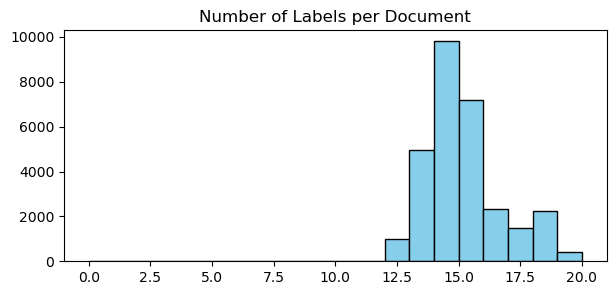

In [15]:
# Step 2.0: Multi-Label Dataset & Loader (로드 및 품질 검증 통합)
import torch
from torch.utils.data import TensorDataset, DataLoader
import os
import matplotlib.pyplot as plt
import numpy as np

# 1.6에서 사용한 save_path와 동일한 경로
load_path = OUT_DIR / "full_processed_data.pt" 

if os.path.exists(load_path):
    # [핵심 수정] weights_only=False를 추가하여 defaultdict 등 파이썬 객체 로드를 허용합니다.
    checkpoint = torch.load(load_path, map_location=device, weights_only=False)
    
    # 1.6에서 저장한 키값 그대로 변수 할당
    train_embs = checkpoint['train_embs'].to(device)
    test_embs = checkpoint['test_embs'].to(device)
    class_embs = checkpoint['class_embs'].to(device)
    train_y = checkpoint['train_y'].to(device).float() 
    
    num_classes = checkpoint['num_classes']
    class_names = checkpoint['class_names']
    parents = checkpoint['parents']
    children = checkpoint['children']
    silver_labels = checkpoint['silver_labels']
    
    # 데이터셋 및 로더 구축
    train_dataset = TensorDataset(train_embs, train_y)
    train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

    print(f"✅ [PyTorch 2.6] 로드 성공: {load_path}")
    print(f"- 데이터: {train_embs.shape}, 레이블: {train_y.shape}")

    # 데이터 분석 로직
    labels_per_doc = train_y.detach().cpu().sum(dim=1).numpy()
    
    print("\n--- Silver Label Analysis ---")
    print(f"Mean labels per doc: {labels_per_doc.mean():.2f}")
    
    empty_docs = np.sum(labels_per_doc == 0)
    if empty_docs > 0:
        print(f"⚠️ Warning: {empty_docs} documents have NO labels.")
    else:
        print("✅ Success: Every document has at least one label.")

    # 시각화
    plt.figure(figsize=(7, 3))
    plt.hist(labels_per_doc, bins=range(int(labels_per_doc.max())+2), color='skyblue', edgecolor='black')
    plt.title("Number of Labels per Document")
    plt.show()

else:
    print(f"❌ 파일을 찾을 수 없습니다: {load_path}")

In [10]:
# Step 2.1:

# GCN용 adjacency (양방향 + self-loop + D^{-1/2} A D^{-1/2})
A = torch.zeros(num_classes, num_classes, dtype=torch.float32)
for p in range(num_classes):
    for c in children[p]:
        A[p, c] = 1.0
        A[c, p] = 1.0

A = A + torch.eye(num_classes)  # self-loop

deg = A.sum(dim=1)
deg_inv_sqrt = torch.where(deg > 0, deg.pow(-0.5), torch.zeros_like(deg))
D_inv_sqrt = torch.diag(deg_inv_sqrt)
A_hat = D_inv_sqrt @ A @ D_inv_sqrt   # [C, C]

# device로 옮기기
A_hat = A_hat.to(device)
class_embs = class_embs.to(device)
train_embs = train_embs.to(device)
silver_labels = silver_labels.to(device)

A_hat.shape
A_hat


tensor([[0.0588, 0.0808, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0808, 0.1111, 0.2357,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.2357, 0.5000,  ..., 0.0000, 0.0000, 0.0000],
        ...,
        [0.0000, 0.0000, 0.0000,  ..., 0.5000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.5000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.5000]],
       device='cuda:0')

In [11]:
# Step 2.2: Dataset & DataLoader

class SilverDataset(Dataset):
    def __init__(self, doc_embs, labels):
        self.doc_embs = doc_embs
        self.labels = labels  # [N, C], values in {1,0,-1}

    def __len__(self):
        return self.doc_embs.size(0)

    def __getitem__(self, idx):
        return self.doc_embs[idx], self.labels[idx]

# train/val split
N = train_embs.size(0)
val_ratio = 0.1
n_val = int(N * val_ratio)
n_train = N - n_val

perm = torch.randperm(N)
train_idx = perm[:n_train]
val_idx = perm[n_train:]

train_ds = SilverDataset(train_embs[train_idx], silver_labels[train_idx])
val_ds   = SilverDataset(train_embs[val_idx],   silver_labels[val_idx])

batch_size = 256
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=False)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, drop_last=False)

print("train_loader:", len(train_loader), "val_loader:", len(val_loader))


train_loader: 104 val_loader: 12


In [12]:
# Step 2.3: Model Setup (인자 전달 및 초기화 수정)

class MultiHeadGCNLayer(nn.Module):
    def __init__(self, num_classes, num_heads=3):
        super().__init__()
        self.num_heads = num_heads
        # 각 Head별로 관계를 다르게 해석하기 위한 학습 가능한 가중치
        self.head_weights = nn.Parameter(torch.ones(num_heads, num_classes))
        
    def forward(self, x, adj):
        # x: [Batch, 531], adj: [531, 531]
        head_outputs = []
        for i in range(self.num_heads):
            # 각 Head마다 특정 레이블에 더 주목하도록 가중치 적용
            weighted_adj = adj * self.head_weights[i].unsqueeze(0)
            out = torch.matmul(weighted_adj, x.t()).t()
            head_outputs.append(out)
        
        # Head들의 결과를 합침 (평균 또는 Concatenation 후 축소)
        return torch.stack(head_outputs).mean(0)

class LabelGCN(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(LabelGCN, self).__init__()
        self.projection = nn.Linear(input_dim, num_classes)
        self.dropout = nn.Dropout(0.3)
        
        # Multi-head 레이어 선언
        self.mh_gcn1 = MultiHeadGCNLayer(num_classes, num_heads=3)
        self.mh_gcn2 = MultiHeadGCNLayer(num_classes, num_heads=3)

    def forward(self, x, adj):
        # 1. 초기 투사 (0.287 모델의 강점 유지)
        x_init = self.projection(x)
        x_init = self.dropout(x_init)
        
        # 2. Multi-head GCN 1단
        out_1 = self.mh_gcn1(x_init, adj)
        out_1 = F.relu(out_1)
        
        # 3. Multi-head GCN 2단
        out_2 = self.mh_gcn2(out_1, adj)
        
        # 4. 0.287 모델의 핵심인 Skip Connection 유지
        # 원본의 힘을 잃지 않으면서 Multi-head의 통찰을 섞음
        final_out = x_init + 0.5 * out_2
        
        return final_out
        
# 1. 인접 행렬 생성
def build_adj_matrix(children, num_classes):
    adj = torch.eye(num_classes)
    for p, c_list in children.items():
        for c in c_list:
            adj[p, c] = 1.0; adj[c, p] = 1.0
    rowsum = adj.sum(1)
    d_inv_sqrt = torch.pow(rowsum, -0.5).flatten()
    d_inv_sqrt[torch.isinf(d_inv_sqrt)] = 0.
    d_mat = torch.diag(d_inv_sqrt)
    return d_mat @ adj @ d_mat

adj_matrix = build_adj_matrix(children, num_classes).to(device)

# 3. 데이터 설정
train_loader = DataLoader(TensorDataset(train_embs, silver_labels.float()), batch_size=256, shuffle=True)

print(f"✅ 모델 준비 완료! 입력 차원: {train_embs.shape[1]}, 클래스 수: {num_classes}")

✅ 모델 준비 완료! 입력 차원: 1024, 클래스 수: 531


In [13]:
# Step 2.4: Training w/ scheduler and Evaluation Loop
model = LabelGCN(input_dim=1024, num_classes=531).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=5e-4) # 감쇠 추가

# 학습률을 서서히 낮춰주는 스케줄러 추가
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)

criterion = nn.BCEWithLogitsLoss()

model.train()
for epoch in range(15):
    total_loss = 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_x, adj_matrix)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    scheduler.step() # 스케줄러 업데이트
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}, LR: {scheduler.get_last_lr()[0]:.6f}")
    
model.eval()

torch.save(model.state_dict(), "upgraded_label_gcn.pt")

Epoch 1, Loss: 0.6837, LR: 0.000495
Epoch 2, Loss: 0.6803, LR: 0.000478
Epoch 3, Loss: 0.6792, LR: 0.000452
Epoch 4, Loss: 0.6787, LR: 0.000417
Epoch 5, Loss: 0.6784, LR: 0.000375
Epoch 6, Loss: 0.6782, LR: 0.000327
Epoch 7, Loss: 0.6780, LR: 0.000276
Epoch 8, Loss: 0.6779, LR: 0.000224
Epoch 9, Loss: 0.6778, LR: 0.000173
Epoch 10, Loss: 0.6777, LR: 0.000125
Epoch 11, Loss: 0.6777, LR: 0.000083
Epoch 12, Loss: 0.6777, LR: 0.000048
Epoch 13, Loss: 0.6776, LR: 0.000022
Epoch 14, Loss: 0.6776, LR: 0.000005
Epoch 15, Loss: 0.6776, LR: 0.000000


여기부터 3단계!!!

In [14]:
# Step 3: Final Format Match (Sample Submission Sync)

model.eval()
with torch.no_grad():
    # 모델 추론 시 adj_matrix 사용
    test_logits = model(test_embs.to(device), adj_matrix.to(device))
    test_probs = torch.sigmoid(test_logits).cpu().numpy()

submission_labels = []
for row in test_probs:
    # 1. 확률 0.5 기준 필터링
    indices = np.where(row > 0.5)[0].tolist()
    
    # 2. 제약 조건 (최소 2개, 최대 3개)
    if len(indices) < 2:
        indices = np.argsort(row)[::-1][:2].tolist()
    elif len(indices) > 3:
        indices = np.argsort(row)[::-1][:3].tolist()
    
    # 3. [형식 맞춤] 정렬된 정수 ID를 컴마로 연결
    # 샘플의 "10,64,93" 형식을 만들기 위해 문자열로 결합
    formatted_row = ",".join(map(str, sorted(indices))) 
    submission_labels.append(formatted_row)

# 4. [핵심] 샘플과 동일한 컬럼명 'id' 사용 (pid 아님)
submission_df = pd.DataFrame({
    "id": test_pids, 
    "label": submission_labels
})

# 5. [저장] index=False는 필수이며, 큰따옴표는 pandas가 자동으로 처리합니다.
output_filename = "2021320312_final.csv"
submission_df.to_csv(output_filename, index=False)

print(f"✅ 샘플과 동일한 형식으로 저장 완료: {output_filename}")
print("-" * 30)
# 저장된 파일의 첫 5줄을 읽어서 형식을 최종 확인합니다.
with open(output_filename, 'r') as f:
    for _ in range(5):
        print(f.readline().strip())

✅ 샘플과 동일한 형식으로 저장 완료: 2021320312_final.csv
------------------------------
id,label
0,"64,65,90"
1,"3,17,168"
2,"3,73,300"
3,"0,8,216"
